# MLP model

Technique:
1. The rolling mean is the average of the previous observation window, where the window consists of a series of values from the time series data. Compute the mean for each ordered window. This can significantly help minimize noise in time series data.
2.  Stratified sampling:
- Stratified sampling involves dividing the population into subpopulations that may differ in important ways. It allows to draw more precise conclusions by ensuring that every subgroup is properly represented in the sample.I sampled 0.01 of the data while still retaining the ratio between the three classes each days.
3. Handle imbalance: I observed that label 2 is twice as frequent as label 1 and label 0. I decided to apply the following method:

- Step 1: I selected a subset of samples from label 2 with a size equal to (samples of label 1+samples of label 2)/2×1.3. The reason for this is to avoid forcing the model to entirely predict new samples as label 2.

- Step 2: I used the model to predict all samples of label 2, sorted them, and extracted the subset with the lowest accuracy, keeping the same size:
(samples of label 1+samples of label 2)/2×1.3


## 1. Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
random_state = 59
np.random.seed(random_state)
torch.manual_seed(random_state)
if torch.cuda.is_available():
    torch.cuda.manual_seed(random_state)

## 2. Data Engineering

In [ ]:
def extract_file_paths(folder_path, file_extension=None):

    file_paths = []
    for root, _, files in os.walk(folder_path):
        for file in files:
            if file_extension and not file.endswith(file_extension):
                continue
            file_paths.append(os.path.join(root, file))
    return file_paths


folder_path = "/kaggle/input/eeg-data"
csv_files = extract_file_paths(folder_path, file_extension=".csv")

In [ ]:
!pip install --upgrade pandas

In [ ]:
def sliding_window(data, label):
    X = pd.DataFrame()
    y = pd.DataFrame()
    data=data.drop('state',axis=1)

    for channel in data.columns:
        rolling = data[channel].rolling(20).mean()
        X[channel] = rolling

    X = X.dropna()

    y = label[:len(X)]
    y = y.reset_index(drop=True)

    return X, y

In [ ]:
import pandas as pd
import numpy as np

def process_sliding_window(dataset, sliding_window):
    X = pd.DataFrame()
    y = pd.DataFrame()

    start = 0
    mapping = {1: 0, 2: 1, 0: 2}
    dataset['state'] = dataset['state'].map(mapping)
    dataset=dataset.drop(['AF3','AF4'],axis=1)

    for state in dataset['state'].unique():

        end = start + np.sum(dataset['state'] == state)

        X_label, y_label = sliding_window(dataset[start:end], dataset['state'][start:end])

        X = pd.concat([X, X_label], ignore_index=True)
        y = pd.concat([y, y_label], ignore_index=True)

        start = end

    return X, y


In [ ]:
def sampling_data(data):
    stratified_sample = data.groupby('state', group_keys=False, dropna=False).apply(
        lambda x: x.sample(frac=0.01, random_state=42), include_groups=False
    )

    stratified_sample['state'] = data.loc[stratified_sample.index, 'state'].values

    return stratified_sample

In [ ]:
X=pd.DataFrame()
y=pd.DataFrame()

for path in csv_files:
    data = pd.read_csv(path)
    stratified_sample = sampling_data(data)
    X_sample,y_sample=process_sliding_window(stratified_sample,sliding_window)
    X = pd.concat([X, X_sample], ignore_index=True)
    y = pd.concat([y, y_sample], ignore_index=True)



## 3. Modeling with raw-data

In [ ]:
y=y.values.reshape(-1)

In [ ]:
val_size=0.2
test_size=0.125
is_shuffle=True

X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=val_size,shuffle=is_shuffle,stratify=y)
X_train,X_test,y_train,y_test=train_test_split(X_train,y_train,test_size=test_size,shuffle=is_shuffle,stratify=y_train)


In [ ]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_val=scaler.transform(X_val)
X_test=scaler.transform(X_test)

X_train=torch.tensor(X_train,dtype=torch.float32)
X_val=torch.tensor(X_val,dtype=torch.float32)
X_test=torch.tensor(X_test,dtype=torch.float32)
y_train=torch.tensor(y_train,dtype=torch.float32)
y_val=torch.tensor(y_val,dtype=torch.float32)
y_test=torch.tensor(y_test,dtype=torch.float32)

### a) Handling with imbalance

In [ ]:
class CustomDataset(Dataset):
  def __init__(self,X,y):
    self.X=X
    self.y=y
  def __len__(self):
    return len(self.X)
  def __getitem__ (self , idx ) :
    return self .X[ idx ] , self .y[ idx ]

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        self.linear1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.linear3 = nn.Linear(hidden_dim, hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.output = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = F.relu(self.bn1(self.linear1(x)))
        x = F.relu(self.bn2(self.linear2(x)))
        x = self.dropout(x)
        x = F.relu(self.bn3(self.linear3(x)))
        x = self.output(x)
        return x


In [ ]:
batch_size = 32
train_dataset = CustomDataset ( X_train , y_train )
val_dataset = CustomDataset (X_val , y_val )
train_loader = DataLoader ( train_dataset ,batch_size = batch_size ,shuffle = True )
val_loader = DataLoader ( val_dataset ,batch_size = batch_size ,shuffle = False )

In [ ]:
class ModelTrainer:
    def __init__(self, model, criterion, optimizer):
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer

    def train(self, train_loader, val_loader, epochs):
        train_losses = []
        val_losses = []

        for epoch in range(epochs):
            train_loss = 0.0
            train_target = []
            train_pred = []
            val_loss = 0.0
            val_target = []
            val_pred = []

            self.model.train()
            for X_samples, y_samples in train_loader:
                X_samples, y_samples = X_samples.to(device), y_samples.to(device)
                self.optimizer.zero_grad()
                y_pred = self.model(X_samples)

                train_target.extend(y_samples.cpu().detach().numpy())
                train_pred.extend(y_pred.cpu().detach().numpy())
                loss = self.criterion(y_pred, y_samples.long())
                train_loss += loss.item()

                loss.backward()
                self.optimizer.step()

            train_losses.append(train_loss / len(train_loader))

            self.model.eval()
            with torch.no_grad():
                for X_samples, y_samples in val_loader:
                    X_samples, y_samples = X_samples.to(device), y_samples.to(device)
                    y_pred = self.model(X_samples)

                    val_target.extend(y_samples.cpu().detach().numpy())
                    val_pred.extend(y_pred.cpu().detach().numpy())
                    loss = self.criterion(y_pred, y_samples.long())
                    val_loss += loss.item()

                val_losses.append(val_loss / len(val_loader))

        return train_losses, val_losses


In [ ]:
input_dim=X_train.shape[1]
hidden_dim=64
output_dim=3
model = MLP(input_dim, hidden_dim, output_dim).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
mask_label_2 = y_train == 2.0
mask_label_01 = ~mask_label_2

X_train_label_2 = X_train[mask_label_2]
y_train_label_2 = y_train[mask_label_2]

X_train_label_01 = X_train[mask_label_01]
y_train_label_01 = y_train[mask_label_01]

In [ ]:
model_MLP=ModelTrainer(model,criterion,optimizer)

model_MLP.model.to(device)

X_train_label_01 = X_train_label_01.to(device)
y_train_label_01 = y_train_label_01.to(device)
X_train_label_2=X_train_label_2.to(device)

In [ ]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader

few_epochs = 1
epochs = 40
check = True
sorted_with_indices = None

for epoch in range(epochs):
    if check:
        idx_random = np.random.choice(len(X_train_label_2), size=int(len(X_train_label_01) / 2 * 1.3), replace=False)
        X_train_label_2_subset = X_train_label_2[idx_random]
        y_train_label_2_subset = y_train_label_2[idx_random]
    else:
        selected_indices = [idx for idx, _ in sorted_with_indices[:int(len(X_train_label_01) / 2 * 1.3)]]
        X_train_label_2_subset = X_train_label_2[selected_indices]
        y_train_label_2_subset = y_train_label_2[selected_indices]

    X_train_combined = torch.cat((X_train_label_01, X_train_label_2_subset), dim=0)
    y_train_combined = torch.cat((y_train_label_01, y_train_label_2_subset.to(device)), dim=0)

    train_dataset = CustomDataset(X_train_combined, y_train_combined)
    val_dataset = CustomDataset(X_val, y_val)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    train_losses, val_losses = model_MLP.train(train_loader, val_loader, few_epochs)

    model_MLP.model.eval()
    with torch.no_grad():
        y_hat = model_MLP.model(X_train_label_2)
        y_pred_labels = torch.argmax(y_hat, dim=1)

        per_sample_accuracy = (y_train_label_2.cpu() == y_pred_labels.cpu()).numpy()

        sorted_with_indices = sorted(enumerate(per_sample_accuracy), key=lambda x: x[1], reverse=True)

        check = False

    print(f'\nEPOCH {epoch + 1}:\tTraining loss: {train_losses[-1]:.3f}\tValidation loss: {val_losses[-1]:.3f}')


EPOCH 1:	Training loss: 0.977	Validation loss: 0.932

EPOCH 2:	Training loss: 0.901	Validation loss: 0.970

EPOCH 3:	Training loss: 0.910	Validation loss: 0.963

EPOCH 4:	Training loss: 0.909	Validation loss: 0.952

EPOCH 5:	Training loss: 0.901	Validation loss: 0.969

EPOCH 6:	Training loss: 0.902	Validation loss: 0.957

EPOCH 7:	Training loss: 0.898	Validation loss: 0.962

EPOCH 8:	Training loss: 0.902	Validation loss: 0.977

EPOCH 9:	Training loss: 0.908	Validation loss: 0.942

EPOCH 10:	Training loss: 0.896	Validation loss: 0.965

EPOCH 11:	Training loss: 0.902	Validation loss: 0.954

EPOCH 12:	Training loss: 0.901	Validation loss: 0.954

EPOCH 13:	Training loss: 0.897	Validation loss: 0.965

EPOCH 14:	Training loss: 0.893	Validation loss: 0.958

EPOCH 15:	Training loss: 0.895	Validation loss: 0.965

EPOCH 16:	Training loss: 0.896	Validation loss: 0.961

EPOCH 17:	Training loss: 0.900	Validation loss: 0.949

EPOCH 18:	Training loss: 0.899	Validation loss: 0.953

EPOCH 19:	Training

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score
from sklearn.preprocessing import label_binarize
import torch
import seaborn as sns
import matplotlib.pyplot as plt

X_test = X_test.to(device)
y_test = y_test.to(device)


model_MLP.model.eval()
with torch.no_grad():
    y_hat_imbalance_handling = model_MLP.model(X_test)
    y_hat_classes_imbalance_handling = torch.argmax(y_hat_imbalance_handling, dim=1)


y_hat_imbalance_handling =y_hat_imbalance_handling.cpu()
y_hat_classes_imbalance_handling = y_hat_classes_imbalance_handling.cpu()
y_test = y_test.cpu()


n_classes = y_hat_imbalance_handling.size(1)
y_test_one_hot = label_binarize(y_test, classes=range(n_classes))

auc_scores_imbalance_handling = roc_auc_score(y_test_one_hot, y_hat_imbalance_handling, average=None, multi_class='ovr')
macro_auc_imbalance_handling = roc_auc_score(y_test_one_hot, y_hat_imbalance_handling, average='macro', multi_class='ovr')

cm_imbalance_handling = confusion_matrix(y_test, y_hat_classes_imbalance_handling)

f1_macro_imbalance_handling = f1_score(y_test, y_hat_classes_imbalance_handling, average='macro')

### b) No handling imbalance

In [ ]:
input_dim=X_train.shape[1]
hidden_dim=64
output_dim=3
model = MLP(input_dim, hidden_dim, output_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
batch_size = 32
train_dataset = CustomDataset ( X_train , y_train )
val_dataset = CustomDataset (X_val , y_val )
train_dataloader = DataLoader ( train_dataset ,batch_size = batch_size ,shuffle = True )
valid_dataloader = DataLoader ( val_dataset ,batch_size = batch_size ,shuffle = False )

In [ ]:
def custom_cel_loss(pred, target):
    cel_loss = nn.CrossEntropyLoss()
    return cel_loss(pred, target)

num_epochs = 40
for epoch in range(num_epochs):

    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for x_batch, y_batch in train_dataloader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device).long()

        optimizer.zero_grad()
        pred = model(x_batch)

        loss = custom_cel_loss(pred, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()


    avg_train_loss = total_loss / len(train_dataloader)



    model.eval()
    val_total_loss = 0
    val_all_preds = []
    val_all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in valid_dataloader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device).long()

            pred = model(x_batch)
            val_loss = custom_cel_loss(pred, y_batch)

            val_total_loss += val_loss.item()

    avg_val_loss = val_total_loss / len(valid_dataloader)

    print(f'\nEPOCH {epoch + 1}:\tTraining loss: {avg_train_loss:.3f}\tValidation loss: {avg_val_loss:.3f}')



EPOCH 1:	Training loss: 1.032	Validation loss: 0.999

EPOCH 2:	Training loss: 1.009	Validation loss: 0.986

EPOCH 3:	Training loss: 0.997	Validation loss: 0.975

EPOCH 4:	Training loss: 0.986	Validation loss: 0.964

EPOCH 5:	Training loss: 0.977	Validation loss: 0.952

EPOCH 6:	Training loss: 0.972	Validation loss: 0.947

EPOCH 7:	Training loss: 0.969	Validation loss: 0.942

EPOCH 8:	Training loss: 0.963	Validation loss: 0.935

EPOCH 9:	Training loss: 0.956	Validation loss: 0.926

EPOCH 10:	Training loss: 0.953	Validation loss: 0.925

EPOCH 11:	Training loss: 0.951	Validation loss: 0.920

EPOCH 12:	Training loss: 0.946	Validation loss: 0.913

EPOCH 13:	Training loss: 0.944	Validation loss: 0.912

EPOCH 14:	Training loss: 0.939	Validation loss: 0.912

EPOCH 15:	Training loss: 0.936	Validation loss: 0.903

EPOCH 16:	Training loss: 0.936	Validation loss: 0.898

EPOCH 17:	Training loss: 0.933	Validation loss: 0.900

EPOCH 18:	Training loss: 0.932	Validation loss: 0.897

EPOCH 19:	Training

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score
from sklearn.preprocessing import label_binarize
import torch
import seaborn as sns
import matplotlib.pyplot as plt

X_test = X_test.to(device)
y_test = y_test.to(device)

model.eval()
with torch.no_grad():
    y_hat_no_imbalance_handling = model(X_test)
    y_hat_classes_no_imbalance_handling = torch.argmax(y_hat_no_imbalance_handling, dim=1)

y_hat_no_imbalance_handling = y_hat_no_imbalance_handling.cpu()
y_hat_classes_no_imbalance_handling = y_hat_classes_no_imbalance_handling.cpu()
y_test = y_test.cpu()

n_classes = y_hat.size(1)
y_test_one_hot = label_binarize(y_test, classes=range(n_classes))

auc_scores_no_imbalance_handling = roc_auc_score(y_test_one_hot, y_hat_no_imbalance_handling, average=None, multi_class='ovr')
macro_auc_no_imbalance_handling = roc_auc_score(y_test_one_hot, y_hat_no_imbalance_handling, average='macro', multi_class='ovr')

cm_no_imbalance_handling = confusion_matrix(y_test, y_hat_classes_no_imbalance_handling)

f1_macro_no_imbalance_handling = f1_score(y_test, y_hat_classes_no_imbalance_handling, average='macro')


### c. Evaluation

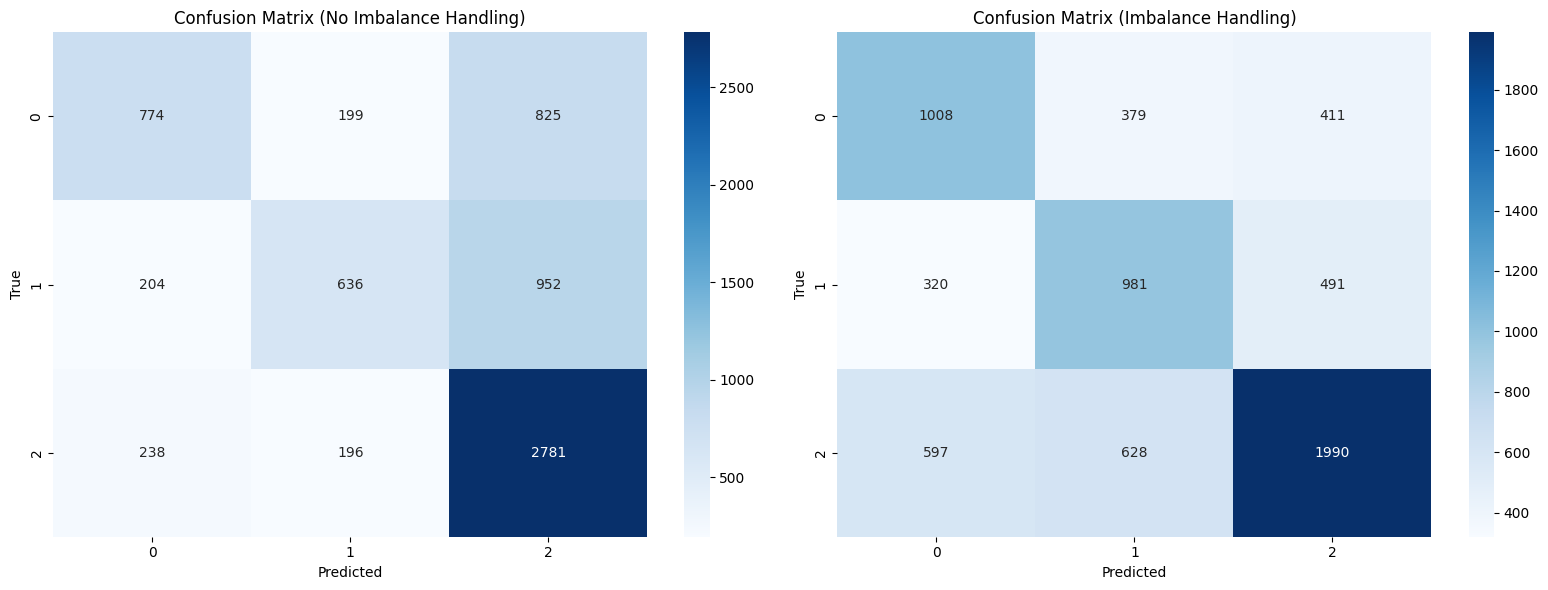

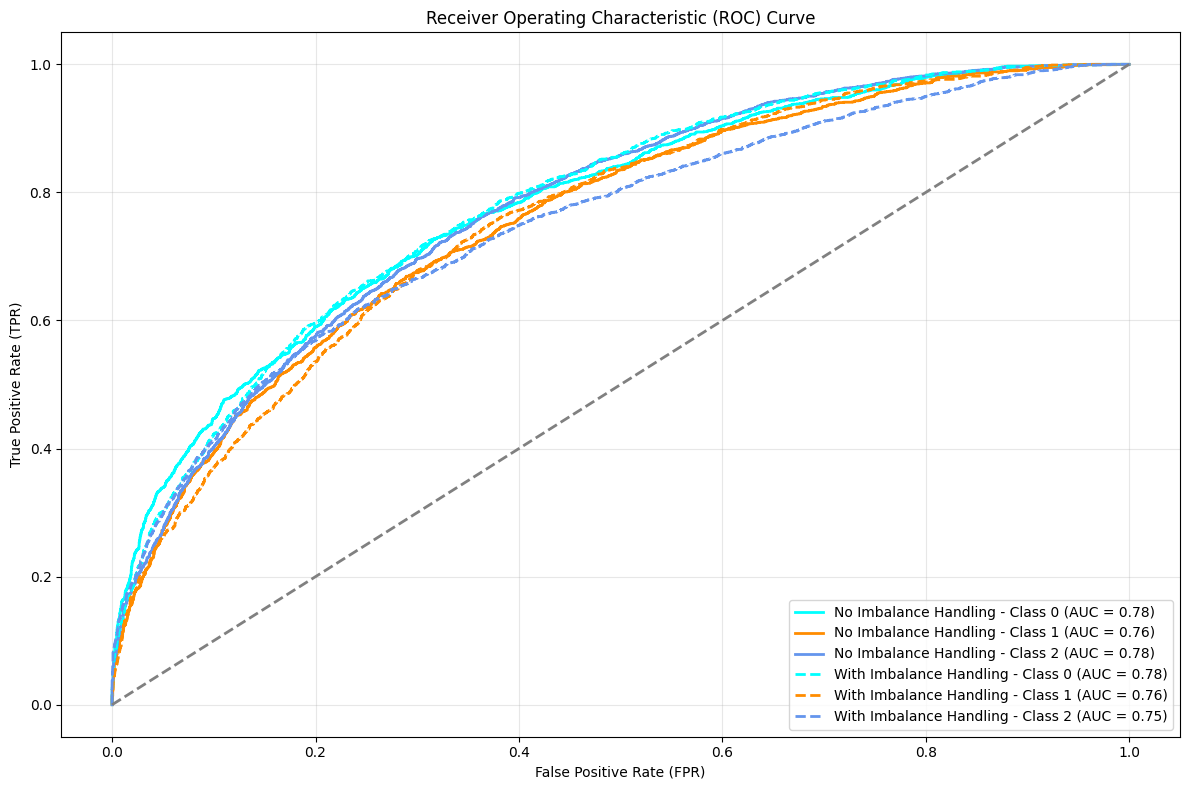

Evaluation without Imbalance Handling:
Class-wise AUC scores: [0.78078066 0.75925907 0.77566907]
Macro-average AUC: 0.7719029315352844
Macro-average F1 Score: 0.5599138366476751
Classification Report:
              precision    recall  f1-score   support

         0.0       0.64      0.43      0.51      1798
         1.0       0.62      0.35      0.45      1792
         2.0       0.61      0.87      0.72      3215

    accuracy                           0.62      6805
   macro avg       0.62      0.55      0.56      6805
weighted avg       0.62      0.62      0.59      6805


Evaluation with Imbalance Handling:
Class-wise AUC scores: [0.78238486 0.75665524 0.75024931]
Macro-average AUC: 0.7630964708506544
Macro-average F1 Score: 0.5707525204943328
Classification Report:
              precision    recall  f1-score   support

         0.0       0.52      0.56      0.54      1798
         1.0       0.49      0.55      0.52      1792
         2.0       0.69      0.62      0.65      3215

 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, roc_curve, auc

def plot_comparison():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(cm_no_imbalance_handling, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(n_classes), yticklabels=range(n_classes), ax=axes[0])
    axes[0].set_title('Confusion Matrix (No Imbalance Handling)')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')

    sns.heatmap(cm_imbalance_handling, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(n_classes), yticklabels=range(n_classes), ax=axes[1])
    axes[1].set_title('Confusion Matrix (Imbalance Handling)')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 8))

    colors = ['aqua', 'darkorange', 'cornflowerblue', 'red', 'green']
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_one_hot[:, i], y_hat_no_imbalance_handling[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2,
                 label=f'No Imbalance Handling - Class {i} (AUC = {roc_auc:.2f})')

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_one_hot[:, i], y_hat_imbalance_handling[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2, linestyle='--',
                 label=f'With Imbalance Handling - Class {i} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)

    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Evaluation without Imbalance Handling:")
    print(f"Class-wise AUC scores: {auc_scores_no_imbalance_handling}")
    print(f"Macro-average AUC: {macro_auc_no_imbalance_handling}")
    print(f"Macro-average F1 Score: {f1_macro_no_imbalance_handling}")
    print("Classification Report:")
    print(classification_report(y_test, y_hat_classes_no_imbalance_handling))

    print("\nEvaluation with Imbalance Handling:")
    print(f"Class-wise AUC scores: {auc_scores_imbalance_handling}")
    print(f"Macro-average AUC: {macro_auc_imbalance_handling}")
    print(f"Macro-average F1 Score: {f1_macro_imbalance_handling}")
    print("Classification Report:")
    print(classification_report(y_test, y_hat_classes_imbalance_handling))

plot_comparison()


1. Confusion Matrix:

The true predictions across the three classes from imbalance handling are more balanced compared to those without imbalance handling. The model's capability to handle imbalance improves predictions for classes 0 and 1.

2. Class-wise AUC Scores:

For 0.5 < AUC < 1.0, the model demonstrates some discrimination ability.
The model can distinguish between positive and negative classes regardless of the classification threshold.

3. F1 Score:

The F1 score and AUC score are not significantly different.

3. Classification Report:

The second method achieves higher overall accuracy and better recall for Class 2, making it preferable when accurately identifying this class is critical.
The first method performs better in Class 0 and Class 1 recall, which may be advantageous if recall for these classes is more important.

## 4. Modeling for data with added features

In [ ]:
import glob

In [ ]:

directory_path = '/kaggle/input/fft-features'


file_paths = glob.glob(f"{directory_path}/*.csv")


data_frames = [pd.read_csv(file) for file in file_paths]
data = pd.concat(data_frames, ignore_index=True)


In [ ]:
data=data.drop('Unnamed: 0',axis=1)

In [ ]:
y=data['state']
X=data.drop('state',axis=1)

In [ ]:
y=y.values.reshape(-1)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
random_state = 59
np.random.seed(random_state)
torch.manual_seed(random_state)
if torch.cuda.is_available():
    torch.cuda.manual_seed(random_state)

In [ ]:
val_size=0.2
test_size=0.125
is_shuffle=True

X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=val_size,shuffle=is_shuffle,stratify=y)
X_train,X_test,y_train,y_test=train_test_split(X_train,y_train,test_size=test_size,shuffle=is_shuffle,stratify=y_train)


In [ ]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_val=scaler.transform(X_val)
X_test=scaler.transform(X_test)

X_train=torch.tensor(X_train,dtype=torch.float32)
X_val=torch.tensor(X_val,dtype=torch.float32)
X_test=torch.tensor(X_test,dtype=torch.float32)
y_train=torch.tensor(y_train,dtype=torch.float32)
y_val=torch.tensor(y_val,dtype=torch.float32)
y_test=torch.tensor(y_test,dtype=torch.float32)

### a) Handling with imbalance

In [ ]:
class CustomDataset(Dataset):
  def __init__(self,X,y):
    self.X=X
    self.y=y
  def __len__(self):
    return len(self.X)
  def __getitem__ (self , idx ) :
    return self .X[ idx ] , self .y[ idx ]

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        self.linear1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.linear3 = nn.Linear(hidden_dim, hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.output = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = F.relu(self.bn1(self.linear1(x)))
        x = F.relu(self.bn2(self.linear2(x)))
        x = self.dropout(x)
        x = F.relu(self.bn3(self.linear3(x)))
        x = self.output(x)
        return x


In [ ]:
batch_size = 32
train_dataset = CustomDataset ( X_train , y_train )
val_dataset = CustomDataset (X_val , y_val )
train_loader = DataLoader ( train_dataset ,batch_size = batch_size ,shuffle = True )
val_loader = DataLoader ( val_dataset ,batch_size = batch_size ,shuffle = False )

In [ ]:
class ModelTrainer:
    def __init__(self, model, criterion, optimizer):
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer

    def train(self, train_loader, val_loader, epochs):
        train_losses = []
        val_losses = []

        for epoch in range(epochs):
            train_loss = 0.0
            train_target = []
            train_pred = []
            val_loss = 0.0
            val_target = []
            val_pred = []

            self.model.train()
            for X_samples, y_samples in train_loader:
                X_samples, y_samples = X_samples.to(device), y_samples.to(device)
                self.optimizer.zero_grad()
                y_pred = self.model(X_samples)

                train_target.extend(y_samples.cpu().detach().numpy())
                train_pred.extend(y_pred.cpu().detach().numpy())
                loss = self.criterion(y_pred, y_samples.long())
                train_loss += loss.item()

                loss.backward()
                self.optimizer.step()

            train_losses.append(train_loss / len(train_loader))

            self.model.eval()
            with torch.no_grad():
                for X_samples, y_samples in val_loader:
                    X_samples, y_samples = X_samples.to(device), y_samples.to(device)
                    y_pred = self.model(X_samples)

                    val_target.extend(y_samples.cpu().detach().numpy())
                    val_pred.extend(y_pred.cpu().detach().numpy())
                    loss = self.criterion(y_pred, y_samples.long())
                    val_loss += loss.item()

                val_losses.append(val_loss / len(val_loader))

        return train_losses, val_losses


In [ ]:
input_dim=X_train.shape[1]
hidden_dim=64
output_dim=3
model = MLP(input_dim, hidden_dim, output_dim).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
mask_label_2 = y_train == 2.0
mask_label_01 = ~mask_label_2

X_train_label_2 = X_train[mask_label_2]
y_train_label_2 = y_train[mask_label_2]

X_train_label_01 = X_train[mask_label_01]
y_train_label_01 = y_train[mask_label_01]

In [ ]:
model_MLP=ModelTrainer(model,criterion,optimizer)

model_MLP.model.to(device)

X_train_label_01 = X_train_label_01.to(device)
y_train_label_01 = y_train_label_01.to(device)
X_train_label_2=X_train_label_2.to(device)

In [ ]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader

few_epochs = 1
epochs = 40
check = True
sorted_with_indices = None

for epoch in range(epochs):
    if check:
        idx_random = np.random.choice(len(X_train_label_2), size=int(len(X_train_label_01) / 2 * 1.3), replace=False)
        X_train_label_2_subset = X_train_label_2[idx_random]
        y_train_label_2_subset = y_train_label_2[idx_random]
    else:
        selected_indices = [idx for idx, _ in sorted_with_indices[:int(len(X_train_label_01) / 2 * 1.3)]]
        X_train_label_2_subset = X_train_label_2[selected_indices]
        y_train_label_2_subset = y_train_label_2[selected_indices]

    X_train_combined = torch.cat((X_train_label_01, X_train_label_2_subset), dim=0)
    y_train_combined = torch.cat((y_train_label_01, y_train_label_2_subset.to(device)), dim=0)

    train_dataset = CustomDataset(X_train_combined, y_train_combined)
    val_dataset = CustomDataset(X_val, y_val)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    train_losses, val_losses = model_MLP.train(train_loader, val_loader, few_epochs)

    model_MLP.model.eval()
    with torch.no_grad():
        y_hat = model_MLP.model(X_train_label_2)
        y_pred_labels = torch.argmax(y_hat, dim=1)

        per_sample_accuracy = (y_train_label_2.cpu() == y_pred_labels.cpu()).numpy()

        sorted_with_indices = sorted(enumerate(per_sample_accuracy), key=lambda x: x[1], reverse=True)

        check = False

    print(f'\nEPOCH {epoch + 1}:\tTraining loss: {train_losses[-1]:.3f}\tValidation loss: {val_losses[-1]:.3f}')


EPOCH 1:	Training loss: 0.855	Validation loss: 0.712

EPOCH 2:	Training loss: 0.704	Validation loss: 0.677

EPOCH 3:	Training loss: 0.668	Validation loss: 0.651

EPOCH 4:	Training loss: 0.646	Validation loss: 0.658

EPOCH 5:	Training loss: 0.628	Validation loss: 0.646

EPOCH 6:	Training loss: 0.619	Validation loss: 0.652

EPOCH 7:	Training loss: 0.608	Validation loss: 0.636

EPOCH 8:	Training loss: 0.601	Validation loss: 0.648

EPOCH 9:	Training loss: 0.599	Validation loss: 0.622

EPOCH 10:	Training loss: 0.597	Validation loss: 0.607

EPOCH 11:	Training loss: 0.604	Validation loss: 0.610

EPOCH 12:	Training loss: 0.594	Validation loss: 0.597

EPOCH 13:	Training loss: 0.596	Validation loss: 0.609

EPOCH 14:	Training loss: 0.592	Validation loss: 0.610

EPOCH 15:	Training loss: 0.578	Validation loss: 0.606

EPOCH 16:	Training loss: 0.575	Validation loss: 0.615

EPOCH 17:	Training loss: 0.572	Validation loss: 0.623

EPOCH 18:	Training loss: 0.566	Validation loss: 0.601

EPOCH 19:	Training

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score
from sklearn.preprocessing import label_binarize
import torch
import seaborn as sns
import matplotlib.pyplot as plt


X_test = X_test.to(device)
y_test = y_test.to(device)


model_MLP.model.eval()
with torch.no_grad():
    y_hat_imbalance_handling = model_MLP.model(X_test)
    y_hat_classes_imbalance_handling = torch.argmax(y_hat_imbalance_handling, dim=1)


y_hat_imbalance_handling =y_hat_imbalance_handling.cpu()
y_hat_classes_imbalance_handling = y_hat_classes_imbalance_handling.cpu()
y_test = y_test.cpu()


n_classes = y_hat_imbalance_handling.size(1)
y_test_one_hot = label_binarize(y_test, classes=range(n_classes))


auc_scores_imbalance_handling = roc_auc_score(y_test_one_hot, y_hat_imbalance_handling, average=None, multi_class='ovr')
macro_auc_imbalance_handling = roc_auc_score(y_test_one_hot, y_hat_imbalance_handling, average='macro', multi_class='ovr')

cm_imbalance_handling = confusion_matrix(y_test, y_hat_classes_imbalance_handling)

f1_macro_imbalance_handling = f1_score(y_test, y_hat_classes_imbalance_handling, average='macro')

### b) No handling with imbalance

In [ ]:
input_dim=X_train.shape[1]
hidden_dim=64
output_dim=3
model = MLP(input_dim, hidden_dim, output_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # Lower learning rate

In [ ]:
batch_size = 32
train_dataset = CustomDataset ( X_train , y_train )
val_dataset = CustomDataset (X_val , y_val )
train_dataloader = DataLoader ( train_dataset ,batch_size = batch_size ,shuffle = True )
valid_dataloader = DataLoader ( val_dataset ,batch_size = batch_size ,shuffle = False )

In [ ]:
import torch
import torch.nn as nn



def custom_cel_loss(pred, target):
    cel_loss = nn.CrossEntropyLoss()
    return cel_loss(pred, target)

num_epochs = 40
for epoch in range(num_epochs):

    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for x_batch, y_batch in train_dataloader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device).long()

        optimizer.zero_grad()
        pred = model(x_batch)

        loss = custom_cel_loss(pred, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()


    avg_train_loss = total_loss / len(train_dataloader)



    model.eval()
    val_total_loss = 0
    val_all_preds = []
    val_all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in valid_dataloader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device).long()

            pred = model(x_batch)
            val_loss = custom_cel_loss(pred, y_batch)

            val_total_loss += val_loss.item()


    avg_val_loss = val_total_loss / len(valid_dataloader)

    print(f'\nEPOCH {epoch + 1}:\tTraining loss: {avg_train_loss:.3f}\tValidation loss: {avg_val_loss:.3f}')



EPOCH 1:	Training loss: 0.746	Validation loss: 0.572

EPOCH 2:	Training loss: 0.621	Validation loss: 0.520

EPOCH 3:	Training loss: 0.576	Validation loss: 0.485

EPOCH 4:	Training loss: 0.547	Validation loss: 0.466

EPOCH 5:	Training loss: 0.530	Validation loss: 0.463

EPOCH 6:	Training loss: 0.516	Validation loss: 0.465

EPOCH 7:	Training loss: 0.502	Validation loss: 0.431

EPOCH 8:	Training loss: 0.496	Validation loss: 0.422

EPOCH 9:	Training loss: 0.487	Validation loss: 0.426

EPOCH 10:	Training loss: 0.483	Validation loss: 0.408

EPOCH 11:	Training loss: 0.474	Validation loss: 0.419

EPOCH 12:	Training loss: 0.469	Validation loss: 0.407

EPOCH 13:	Training loss: 0.464	Validation loss: 0.402

EPOCH 14:	Training loss: 0.464	Validation loss: 0.402

EPOCH 15:	Training loss: 0.457	Validation loss: 0.403

EPOCH 16:	Training loss: 0.452	Validation loss: 0.389

EPOCH 17:	Training loss: 0.450	Validation loss: 0.394

EPOCH 18:	Training loss: 0.449	Validation loss: 0.395

EPOCH 19:	Training

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score
from sklearn.preprocessing import label_binarize
import torch
import seaborn as sns
import matplotlib.pyplot as plt


X_test = X_test.to(device)
y_test = y_test.to(device)

model.eval()
with torch.no_grad():
    y_hat_no_imbalance_handling = model(X_test)
    y_hat_classes_no_imbalance_handling = torch.argmax(y_hat_no_imbalance_handling, dim=1)


y_hat_no_imbalance_handling = y_hat_no_imbalance_handling.cpu()
y_hat_classes_no_imbalance_handling = y_hat_classes_no_imbalance_handling.cpu()
y_test = y_test.cpu()


n_classes = y_hat.size(1)
y_test_one_hot = label_binarize(y_test, classes=range(n_classes))

auc_scores_no_imbalance_handling = roc_auc_score(y_test_one_hot, y_hat_no_imbalance_handling, average=None, multi_class='ovr')
macro_auc_no_imbalance_handling = roc_auc_score(y_test_one_hot, y_hat_no_imbalance_handling, average='macro', multi_class='ovr')

cm_no_imbalance_handling = confusion_matrix(y_test, y_hat_classes_no_imbalance_handling)

f1_macro_no_imbalance_handling = f1_score(y_test, y_hat_classes_no_imbalance_handling, average='macro')


### c) Evalutation

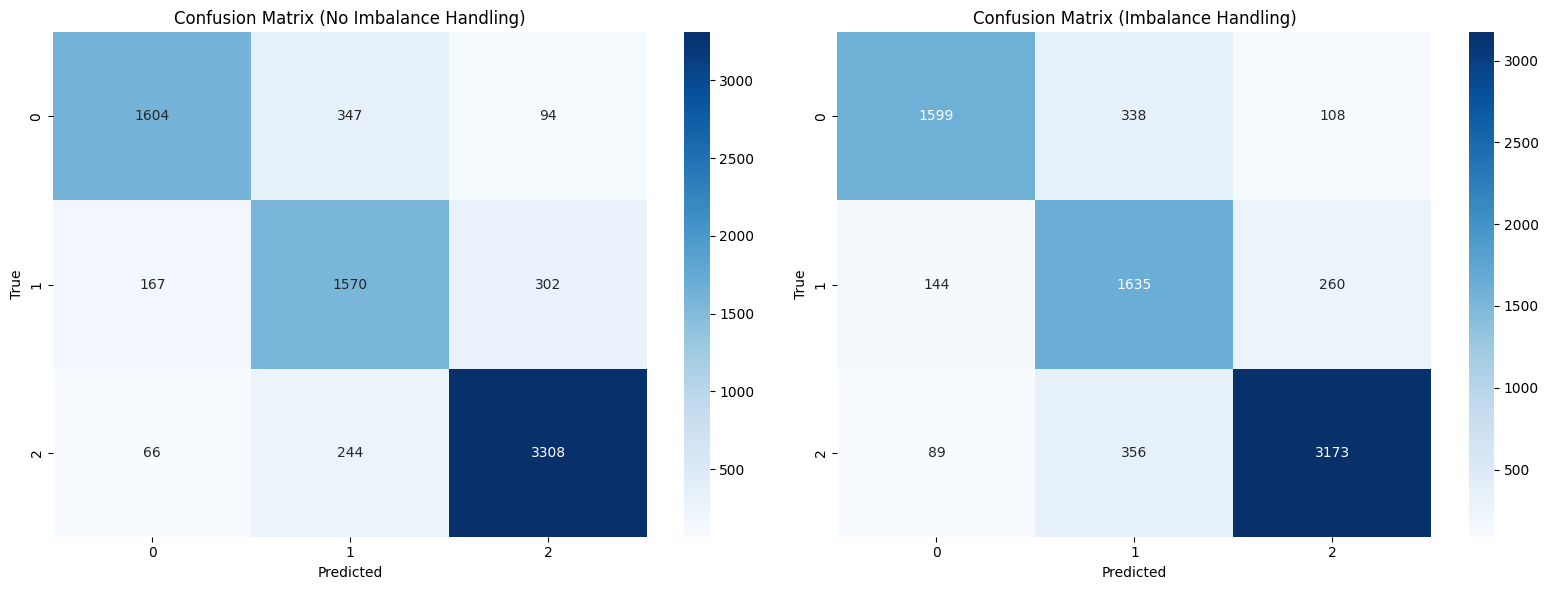

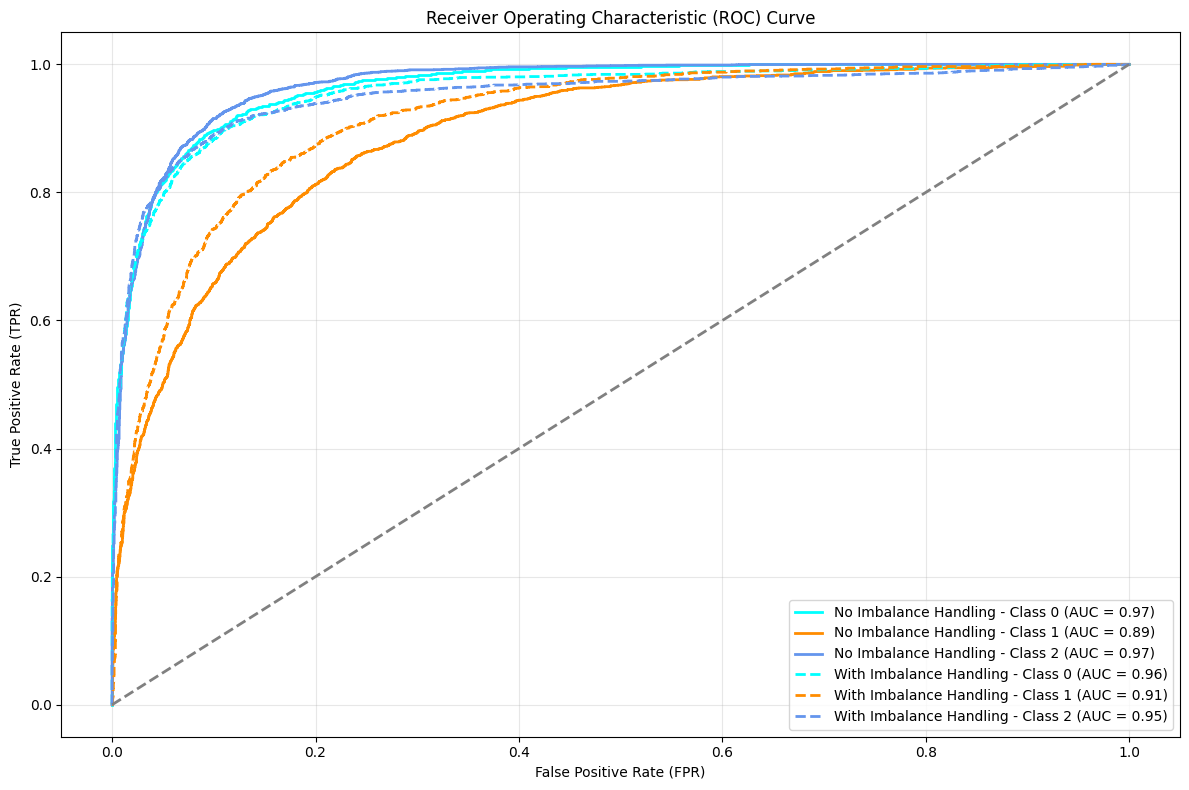

Evaluation without Imbalance Handling:
Class-wise AUC scores: [0.96503222 0.88982993 0.96836398]
Macro-average AUC: 0.941075380041244
Macro-average F1 Score: 0.8258584868385656
Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.78      0.83      2045
         1.0       0.73      0.77      0.75      2039
         2.0       0.89      0.91      0.90      3618

    accuracy                           0.84      7702
   macro avg       0.83      0.82      0.83      7702
weighted avg       0.84      0.84      0.84      7702


Evaluation with Imbalance Handling:
Class-wise AUC scores: [0.95606992 0.91431582 0.94965062]
Macro-average AUC: 0.9400121190167808
Macro-average F1 Score: 0.8199758709367807
Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.78      0.82      2045
         1.0       0.70      0.80      0.75      2039
         2.0       0.90      0.88      0.89      3618

  

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, roc_curve, auc

def plot_comparison():

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))


    sns.heatmap(cm_no_imbalance_handling, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(n_classes), yticklabels=range(n_classes), ax=axes[0])
    axes[0].set_title('Confusion Matrix (No Imbalance Handling)')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')


    sns.heatmap(cm_imbalance_handling, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(n_classes), yticklabels=range(n_classes), ax=axes[1])
    axes[1].set_title('Confusion Matrix (Imbalance Handling)')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')

    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(12, 8))


    colors = ['aqua', 'darkorange', 'cornflowerblue', 'red', 'green']
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_one_hot[:, i], y_hat_no_imbalance_handling[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2,
                 label=f'No Imbalance Handling - Class {i} (AUC = {roc_auc:.2f})')


    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_one_hot[:, i], y_hat_imbalance_handling[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2, linestyle='--',
                 label=f'With Imbalance Handling - Class {i} (AUC = {roc_auc:.2f})')


    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)


    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


    print("Evaluation without Imbalance Handling:")
    print(f"Class-wise AUC scores: {auc_scores_no_imbalance_handling}")
    print(f"Macro-average AUC: {macro_auc_no_imbalance_handling}")
    print(f"Macro-average F1 Score: {f1_macro_no_imbalance_handling}")
    print("Classification Report:")
    print(classification_report(y_test, y_hat_classes_no_imbalance_handling))

    print("\nEvaluation with Imbalance Handling:")
    print(f"Class-wise AUC scores: {auc_scores_imbalance_handling}")
    print(f"Macro-average AUC: {macro_auc_imbalance_handling}")
    print(f"Macro-average F1 Score: {f1_macro_imbalance_handling}")
    print("Classification Report:")
    print(classification_report(y_test, y_hat_classes_imbalance_handling))
plot_comparison()



1. Confusion Matrix:
The inclusion of imbalance handling is a positive step toward improving the fairness and overall balance of the model's predictions, especially for the underperforming class (class 1).
2. F1 Score: The F1 score and AUC score are not significantly different.

3. Classification Report: Without Imbalance Handling: The model achieves 0.84 accuracy, which is good, but macro-average F1-score (0.83) indicates room for improvement, especially in handling imbalanced data. With Imbalance Handling: The accuracy remains the same (0.84), but the performance balance across classes improves.

=> Imbalance handling is beneficial for improving the performance balance between classes, particularly for the underperforming class (class 1)
